In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Khai báo đường dẫn và tạo thư mục output

In [11]:
input_folder = "anh_xlas/anh_xlas"
output_folder = "output_cau2"

os.makedirs(output_folder, exist_ok=True)

image_files = sorted([
    f for f in os.listdir(input_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
])

print("Số ảnh tìm thấy:", len(image_files))

Số ảnh tìm thấy: 10


# Đọc ảnh

In [12]:
for filename in image_files:

    image_path = os.path.join(input_folder, filename)

    img = cv2.imread(image_path)

    if img is None:
        print(f"Không đọc được {filename}")
        continue

# Chuyển ảnh xám

In [13]:
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

# Tạo kernel và thực hiện tích chập

In [14]:
    kernel3 = np.ones((3, 3), dtype=np.float32) / 9
    kernel5 = np.ones((5, 5), dtype=np.float32) / 25
    kernel7 = np.ones((7, 7), dtype=np.float32) / 49

    # I1
    I1 = cv2.filter2D(
        gray,
        -1,
        kernel3,
        borderType=cv2.BORDER_CONSTANT
    )

    # I2
    I2 = cv2.filter2D(
        gray,
        -1,
        kernel5,
        borderType=cv2.BORDER_CONSTANT
    )

    # I3
    temp = cv2.filter2D(
        gray,
        -1,
        kernel7,
        borderType=cv2.BORDER_CONSTANT
    )

    # stride = 2
    I3 = temp[::2, ::2]

# Median Filter

In [15]:
    I4 = cv2.medianBlur(
        I3,
        3
    )

    I5 = cv2.medianBlur(
        I1,
        5
    )

# Tạo ảnh I6

In [16]:
    h4, w4 = I4.shape
    h5, w5 = I5.shape

    new_h = max(h4, h5)
    new_w = max(w4, w5)

    pad_I4 = np.zeros(
        (new_h, new_w),
        dtype=np.uint8
    )

    pad_I5 = np.zeros(
        (new_h, new_w),
        dtype=np.uint8
    )

    pad_I4[:h4, :w4] = I4
    pad_I5[:h5, :w5] = I5

    I6 = np.where(
        pad_I4 > pad_I5,
        0,
        pad_I5
    )

    I6 = I6.astype(np.uint8)

# Hiển thị kết quả

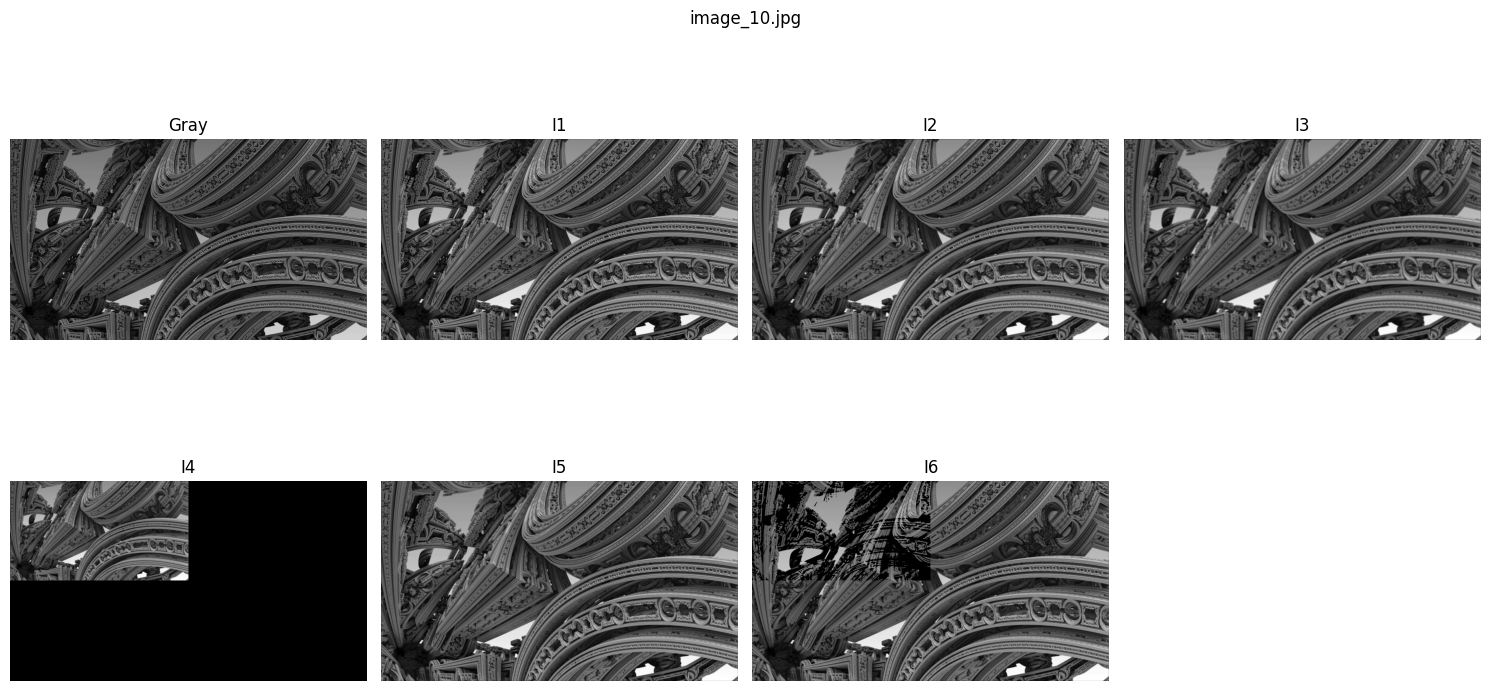

In [17]:
    titles = [
        "Gray",
        "I1",
        "I2",
        "I3",
        "I4",
        "I5",
        "I6"
    ]

    images = [
        gray,
        I1,
        I2,
        I3,
        pad_I4,
        pad_I5,
        I6
    ]

    plt.figure(figsize=(15, 8))

    for i in range(len(images)):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(filename)

    plt.tight_layout()
    plt.show()

# Lưu kết quả

In [18]:
    name = os.path.splitext(filename)[0]

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"Gray_{name}.jpg"
        ),
        gray
    )

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"I1_{name}.jpg"
        ),
        I1
    )

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"I2_{name}.jpg"
        ),
        I2
    )

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"I3_{name}.jpg"
        ),
        I3
    )

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"I4_{name}.jpg"
        ),
        pad_I4
    )

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"I5_{name}.jpg"
        ),
        pad_I5
    )

    cv2.imwrite(
        os.path.join(
            output_folder,
            f"I6_{name}.jpg"
        ),
        I6
    )

    print(f"Processing {filename} ... Done!")

print(f"\nFinished processing {len(image_files)} images.")

Processing image_10.jpg ... Done!

Finished processing 10 images.
